In [ ]:
import os
import re
import pandas as pd
from collections import defaultdict

BASE_DIR = "results_docking"

# regex to capture vina affinity lines
affinity_pattern = re.compile(r"^\s*1\s+(-?\d+\.\d+)\s+")

data = []

for protein in os.listdir(BASE_DIR):
    protein_path = os.path.join(BASE_DIR, protein)
    if not os.path.isdir(protein_path):
        continue

    for ligand in os.listdir(protein_path):
        ligand_path = os.path.join(protein_path, ligand)
        if not os.path.isdir(ligand_path):
            continue

        for file in os.listdir(ligand_path):
            if not file.endswith(".log"):
                continue

            log_path = os.path.join(ligand_path, file)

            # extract replicate number if exists
            rep_match = re.search(r"rep(\d+)", file)
            rep = int(rep_match.group(1)) if rep_match else None

            affinity = None

            with open(log_path, "r") as f:
                for line in f:
                    m = affinity_pattern.match(line)
                    if m:
                        affinity = float(m.group(1))
                        break

            if affinity is not None:
                data.append({
                    "protein": protein,
                    "ligand": ligand,
                    "replicate": rep,
                    "affinity": affinity
                })

df = pd.DataFrame(data)


In [2]:
df

,protein,ligand,replicate,affinity
0,PDE4B_catalytic,no17,2,-6.4
1,PDE4B_catalytic,no17,3,-6.3
2,PDE4B_catalytic,no17,1,-6.4
3,PDE4B_catalytic,107,3,-6.2
4,PDE4B_catalytic,107,2,-6.2
...,...,...,...,...
139,PDE4D_catalytic,roflumilast,2,-9.2
140,PDE4D_catalytic,roflumilast,3,-9.1
141,PDE4D_catalytic,no7,1,-7.5
142,PDE4D_catalytic,no7,2,-7.6


In [3]:
# ---- per replicate table ----
print("\n=== PER REPLICATE ===")
print(df.sort_values(["protein", "ligand", "replicate"]))



=== PER REPLICATE ===
             protein       ligand  replicate  affinity
11   PDE4B_catalytic       104775          1      -3.7
9    PDE4B_catalytic       104775          2      -3.7
10   PDE4B_catalytic       104775          3      -3.7
29   PDE4B_catalytic     10559720          1      -6.6
28   PDE4B_catalytic     10559720          2      -6.6
..               ...          ...        ...       ...
139  PDE4D_catalytic  roflumilast          2      -9.2
140  PDE4D_catalytic  roflumilast          3      -9.1
116  PDE4D_catalytic     rolipram          1      -9.0
115  PDE4D_catalytic     rolipram          2      -9.0
114  PDE4D_catalytic     rolipram          3      -9.0

[144 rows x 4 columns]


In [4]:
# ---- per ligand mean/std ----
summary = (
    df.groupby(["protein", "ligand"])
      .agg(mean_affinity=("affinity", "mean"),
           std_affinity=("affinity", "std"),
           n=("affinity", "count"))
      .reset_index()
)

print("\n=== SUMMARY (MEAN ± STD) ===")
print(summary.sort_values(["protein", "mean_affinity"]))



=== SUMMARY (MEAN ± STD) ===
             protein       ligand  mean_affinity  std_affinity  n
10   PDE4B_catalytic  roflumilast      -8.033333      0.057735  3
11   PDE4B_catalytic     rolipram      -7.600000      0.000000  3
9    PDE4B_catalytic          no7      -6.966667      0.152753  3
4    PDE4B_catalytic     49831816      -6.666667      0.057735  3
6    PDE4B_catalytic         no12      -6.666667      0.057735  3
1    PDE4B_catalytic     10559720      -6.600000      0.000000  3
7    PDE4B_catalytic         no13      -6.400000      0.000000  3
8    PDE4B_catalytic         no17      -6.366667      0.057735  3
2    PDE4B_catalytic          107      -6.200000      0.000000  3
5    PDE4B_catalytic         6047      -6.200000      0.000000  3
3    PDE4B_catalytic       348154      -6.133333      0.057735  3
0    PDE4B_catalytic       104775      -3.700000      0.000000  3
22  PDE4B_catalytic2  roflumilast      -8.100000      0.000000  3
23  PDE4B_catalytic2     rolipram      -7.4666

In [65]:
df

,protein,ligand,replicate,affinity
0,PDE4B_catalytic,no17,2,-7.0
1,PDE4B_catalytic,no17,3,-7.1
2,PDE4B_catalytic,no17,1,-6.9
3,PDE4B_catalytic,107,3,-6.6
4,PDE4B_catalytic,107,2,-6.7
...,...,...,...,...
139,PDE4D_catalytic,roflumilast,2,-9.2
140,PDE4D_catalytic,roflumilast,3,-9.1
141,PDE4D_catalytic,no7,1,-7.5
142,PDE4D_catalytic,no7,2,-7.6


In [5]:
df.to_csv("vina_replicates.csv", index=False)
summary.to_csv("vina_summary.csv", index=False)

In [7]:
summary

,protein,ligand,mean_affinity,std_affinity,n
0,PDE4B_catalytic,104775,-3.700000,0.000000,3
1,PDE4B_catalytic,10559720,-6.600000,0.000000,3
2,PDE4B_catalytic,107,-6.200000,0.000000,3
3,PDE4B_catalytic,348154,-6.133333,0.057735,3
4,PDE4B_catalytic,49831816,-6.666667,0.057735,3
5,PDE4B_catalytic,6047,-6.200000,0.000000,3
6,PDE4B_catalytic,no12,-6.666667,0.057735,3
7,PDE4B_catalytic,no13,-6.400000,0.000000,3
8,PDE4B_catalytic,no17,-6.366667,0.057735,3
9,PDE4B_catalytic,no7,-6.966667,0.152753,3


/tmp/ipykernel_24593/1048378106.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub["ligand"], rotation=45)
/tmp/ipykernel_24593/1048378106.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub["ligand"], rotation=45)
/tmp/ipykernel_24593/1048378106.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub["ligand"], rotation=45)
/tmp/ipykernel_24593/1048378106.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(sub["ligand"], rotation=45)


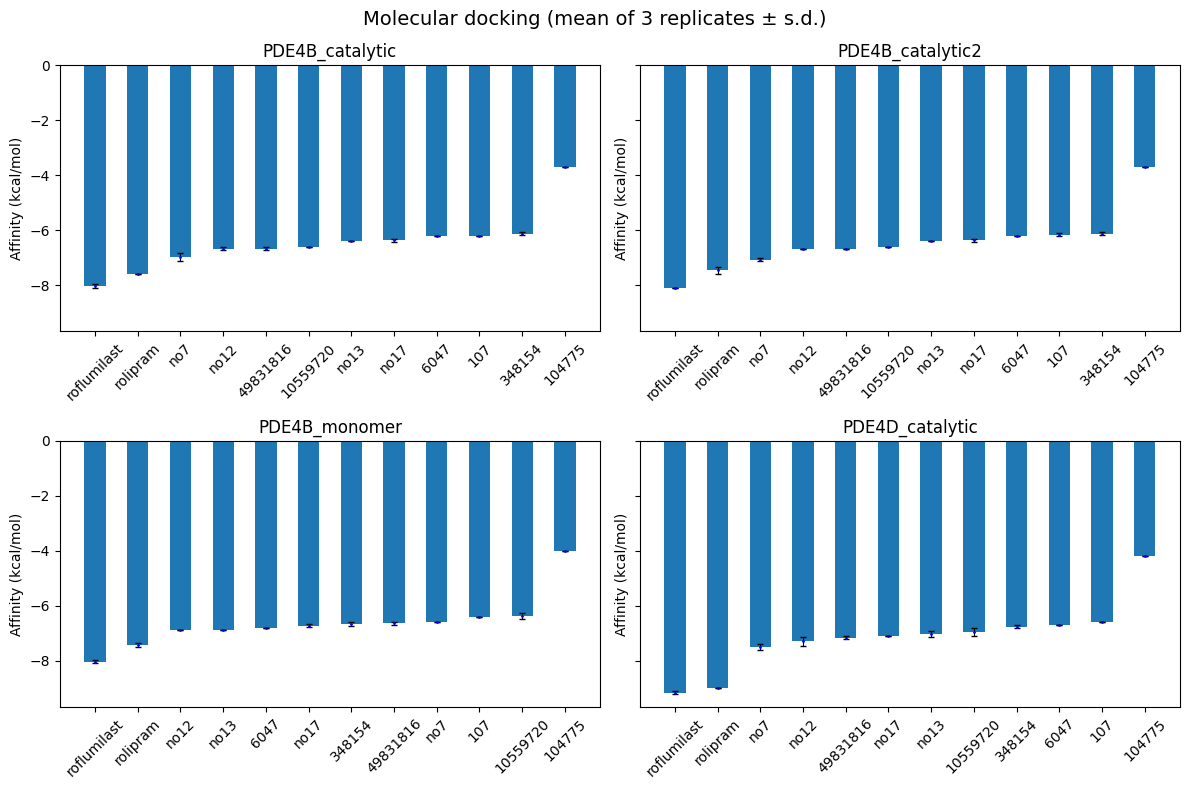

In [6]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
axes = axes.ravel()
proteins = df["protein"].unique()

for ax, protein in zip(axes, proteins):
    sub = summary[summary["protein"] == protein].sort_values("mean_affinity")
    ax.bar(sub["ligand"], sub["mean_affinity"], width=0.5)
    ax.errorbar(
        sub["ligand"],
        sub["mean_affinity"],
        yerr=sub["std_affinity"],
        fmt="o",
        color="blue",
        ecolor="black",
        elinewidth=0.8,
        capsize=2,
        markersize=1
    )

    ax.set_title(protein)
    ax.set_xticklabels(sub["ligand"], rotation=45)
    ax.set_ylabel("Affinity (kcal/mol)")

fig.suptitle("Molecular docking (mean of 3 replicates ± s.d.)", fontsize=14)
plt.tight_layout()
plt.savefig("docking_comparison.png", dpi=300)
plt.show()

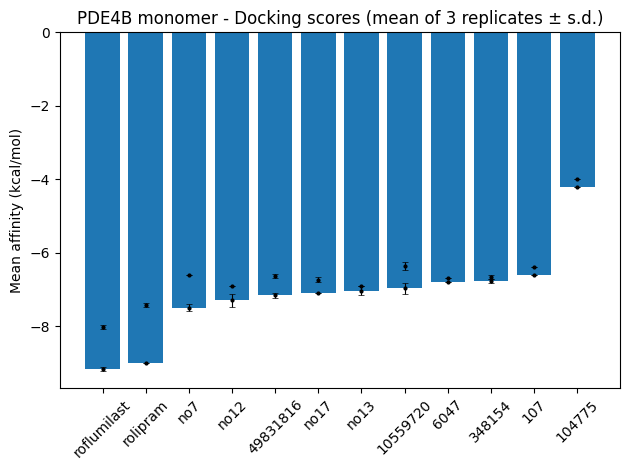

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("vina_summary.csv")

# sort by best (most negative)
df = df.sort_values("mean_affinity")

plt.figure()
plt.bar(df["ligand"], df["mean_affinity"])
plt.errorbar(
    df["ligand"],
    df["mean_affinity"],
    yerr=df["std_affinity"],
    fmt="o",
    color="black",          
    ecolor="black",         
    elinewidth=0.8,         
    capsize=2,              
    capthick=0.5,           
    markersize=2
)

plt.xticks(rotation=45)
plt.ylabel("Mean affinity (kcal/mol)")
plt.title("PDE4B monomer - Docking scores (mean of 3 replicates ± s.d.)")
plt.tight_layout()
plt.show()


